# PulseIA — Classificador de risco textual

Fase 2 • Grupo PulseIA

Este exercício transforma frases simuladas em vetores TF-IDF e treina uma Regressão Logística para distinguir `alto risco` e `baixo risco`. Os rótulos foram definidos para a atividade, sem validação clínica. Não correspondem a diagnósticos nem autorizam decisões de atendimento.

Execute as células em ordem. A base numérica da Fase 1 permanece como referência de governança; não usamos seu alvo artificial para rotular estas frases. As imagens e os textos institucionais da Fase 1 não são dados de treinamento deste classificador.

In [1]:
from pathlib import Path
import sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "fase2/data/frases_risco.csv").exists())
SAIDA = RAIZ / "fase2/outputs"
SAIDA.mkdir(exist_ok=True)
SEED = 42
CLASSES = ["baixo risco", "alto risco"]
dados = pd.read_csv(RAIZ / "fase2/data/frases_risco.csv")
assert not dados.isna().any().any()
assert set(dados.situacao) == set(CLASSES)
assert not dados.frase.str.lower().str.strip().duplicated().any()
assert dados.groupby("grupo").situacao.nunique().eq(1).all()
display(dados.head())

,frase,situacao,grupo
0,Dor no peito começou de repente e estou suando...,alto risco,A01
1,Sinto pressão no tórax acompanhada de suor gel...,alto risco,A01
2,Estou sem ar mesmo sentado e não consigo falar...,alto risco,A02
3,A respiração ficou difícil em repouso e mal co...,alto risco,A02
4,Desmaiei durante a caminhada e continuo muito ...,alto risco,A03


## 1. Composição e limites da base

São 80 frases em português, organizadas em 40 cenários com duas paráfrases cada. As classes estão equilibradas por construção, e não pela frequência de situações observadas em um serviço de saúde. `grupo` serve apenas para separar os cenários e nunca entra como atributo do modelo.

Muitos exemplos de baixo risco descrevem queixas leves não cardíacas; isso pode facilitar a tarefa por vocabulário. Pares de negação e exemplos com diabetes foram incluídos, mas não cobrem toda a complexidade da linguagem. Dois textos institucionais não seriam suficientes para representar relatos de pacientes.

In [2]:
perfil = dados.groupby("situacao").agg(frases=("frase", "size"), grupos=("grupo", "nunique"))
perfil["percentual"] = perfil.frases / len(dados) * 100
display(perfil)
dados["palavras"] = dados.frase.str.split().str.len()
display(dados.groupby("situacao").palavras.agg(["min", "median", "mean", "max"]))
print("Duplicatas exatas:", dados.frase.duplicated().sum())

,frases,grupos,percentual
situacao,,,
alto risco,40,20,50.0
baixo risco,40,20,50.0


,min,median,mean,max
situacao,,,,
alto risco,8,10.0,9.950,14
baixo risco,7,11.0,10.925,14


Duplicatas exatas: 0


## 2. Separação por cenário antes do TF-IDF

Reservamos 20% dos grupos para o teste final. A estratificação mantém a proporção das classes. As duas paráfrases de um cenário ficam no mesmo conjunto. O TF-IDF é ajustado dentro de um Pipeline, apenas com o treino; assim, não aprende o vocabulário nem a frequência dos termos do teste.

A separação por grupo reduz vazamento por paráfrases conhecidas. Expressões semelhantes ainda podem existir entre cenários diferentes. Todo o corpus compartilha a mesma origem sintética.

In [3]:
grupos = dados[["grupo", "situacao"]].drop_duplicates()
g_treino, g_teste = train_test_split(grupos.grupo, test_size=0.2,
                                   random_state=SEED, stratify=grupos.situacao)
treino = dados[dados.grupo.isin(g_treino)].copy()
teste = dados[dados.grupo.isin(g_teste)].copy()
assert set(treino.grupo).isdisjoint(teste.grupo)
assert set(treino.frase).isdisjoint(teste.frase)
display(pd.crosstab(dados.situacao, np.where(dados.grupo.isin(g_treino), "treino", "teste")))
divisao = dados[["frase", "situacao", "grupo"]].copy()
divisao["conjunto"] = np.where(dados.grupo.isin(g_treino), "treino", "teste")
divisao.to_csv(SAIDA / "divisao_dados.csv", index=False)

col_0,teste,treino
situacao,,
alto risco,8,32
baixo risco,8,32


## 3. TF-IDF e treinamento

Usamos unigramas e bigramas para representar termos e pequenas expressões. Mantemos palavras como “não” e “sem”, relevantes para negação, embora isso não garanta compreensão do contexto. A Regressão Logística foi escolhida pela simplicidade e possibilidade de inspecionar coeficientes.

A configuração é fixa. A validação cruzada acontece somente no treino, com quatro divisões por grupo. Não escolhemos a seed ou os parâmetros para melhorar o resultado do teste.

In [4]:
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2))),
    ("classificador", LogisticRegression(max_iter=1000, random_state=SEED))
])
cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
cv_resultados = cross_validate(modelo, treino.frase, treino.situacao,
    groups=treino.grupo, cv=cv, scoring={"acuracia": "accuracy", "f1_macro": "f1_macro"})
display(pd.DataFrame({k: v for k, v in cv_resultados.items() if k.startswith("test_")}))
modelo.fit(treino.frase, treino.situacao)
print("Vocabulário do treino:", len(modelo.named_steps["tfidf"].vocabulary_))
print("Formato dos vetores:", modelo.named_steps["tfidf"].transform(treino.frase).shape)

,test_acuracia,test_f1_macro
0,0.8125,0.811765
1,0.8750,0.873016
2,0.6875,0.686275
3,0.9375,0.937255


Vocabulário do treino: 705
Formato dos vetores: (64, 705)


## 4. Avaliação no teste reservado

Além da acurácia, calculamos precisão, recall e F1 por classe. Em uma simulação de triagem, observar falsos negativos de alto risco é essencial: a acurácia isolada esconde esse tipo de erro. O DummyClassifier prevê sempre a classe mais frequente e fornece uma referência mínima.

O conjunto de teste tem poucos exemplos e apenas oito cenários independentes; os resultados são instáveis e não validam uso em pacientes.

,precision,recall,f1-score,support
baixo risco,0.875,0.875,0.875,8.000
alto risco,0.875,0.875,0.875,8.000
accuracy,0.875,0.875,0.875,0.875
macro avg,0.875,0.875,0.875,16.000
weighted avg,0.875,0.875,0.875,16.000


Acurácia do baseline: 0.5


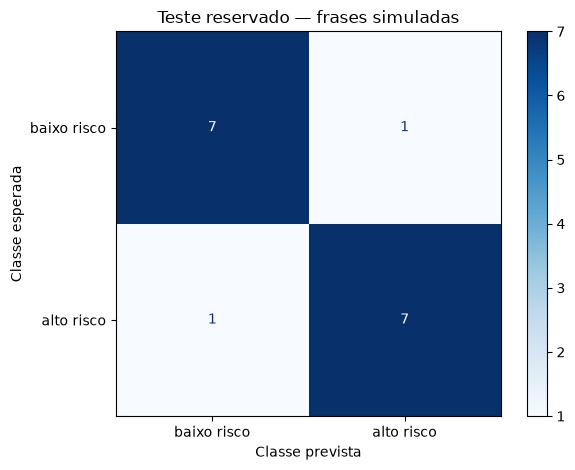

,frase,situacao,grupo,predicao,acerto
12,Sinto dor intensa no peito que não passa há me...,alto risco,A07,alto risco,True
13,Uma dor forte no tórax continua mesmo após par...,alto risco,A07,alto risco,True
14,Estou com lábios arroxeados e dificuldade para...,alto risco,A08,baixo risco,False
15,Minha boca ficou roxa enquanto eu tentava puxa...,alto risco,A08,alto risco,True
20,Uma dor súbita muito forte atravessa o peito e...,alto risco,A11,alto risco,True
21,Surgiu uma dor intensa no tórax que se espalho...,alto risco,A11,alto risco,True
28,A pressão no peito piora e estou quase apagando.,alto risco,A15,alto risco,True
29,Sinto aperto crescente no tórax e sensação de ...,alto risco,A15,alto risco,True
40,Senti cansaço leve após correr e já passou com...,baixo risco,B01,baixo risco,True
41,Fiquei cansado depois do exercício mas me recu...,baixo risco,B01,baixo risco,True


Erros a examinar:


,frase,situacao,grupo,predicao,acerto
14,Estou com lábios arroxeados e dificuldade para...,alto risco,A08,baixo risco,False
63,Fiquei com irritação discreta no olho após lim...,baixo risco,B12,alto risco,False


1107

In [5]:
predicoes = modelo.predict(teste.frase)
dummy = DummyClassifier(strategy="most_frequent").fit(treino[["palavras"]], treino.situacao)
baseline = accuracy_score(teste.situacao, dummy.predict(teste[["palavras"]]))
relatorio = classification_report(teste.situacao, predicoes, labels=CLASSES,
                                  output_dict=True, zero_division=0)
display(pd.DataFrame(relatorio).T)
print("Acurácia do baseline:", baseline)
matriz = confusion_matrix(teste.situacao, predicoes, labels=CLASSES)
ConfusionMatrixDisplay(matriz, display_labels=CLASSES).plot(cmap="Blues")
plt.title("Teste reservado — frases simuladas")
plt.xlabel("Classe prevista")
plt.ylabel("Classe esperada")
plt.tight_layout()
plt.savefig(SAIDA / "matriz_confusao.png", dpi=160)
plt.show()
resultados = teste[["frase", "situacao", "grupo"]].copy()
resultados["predicao"] = predicoes
resultados["acerto"] = resultados.situacao == resultados.predicao
resultados.to_csv(SAIDA / "predicoes_teste.csv", index=False)
display(resultados)
print("Erros a examinar:")
display(resultados[~resultados.acerto])
metricas = {"seed": SEED, "n_treino": len(treino), "n_teste": len(teste),
            "grupos_treino": treino.grupo.nunique(), "grupos_teste": teste.grupo.nunique(),
            "baseline_acuracia": baseline, "relatorio": relatorio,
            "matriz_confusao": matriz.tolist(),
            "cv_acuracia": cv_resultados["test_acuracia"].tolist(),
            "cv_f1_macro": cv_resultados["test_f1_macro"].tolist(),
            "sha256_dataset": hashlib.sha256((RAIZ / "fase2/data/frases_risco.csv").read_bytes()).hexdigest(),
            "python": platform.python_version(), "sklearn": sklearn.__version__,
            "numpy": np.__version__, "pandas": pd.__version__}
(SAIDA / "metricas.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")

## 5. Vocabulário e distorções

Coeficientes representam associações aprendidas nos exemplos. Não são fatores de risco clínico. Verificamos se termos como “leve” dominam a classe de baixo risco ou se palavras isoladas de sintomas determinam alto risco.

In [6]:
vetor = modelo.named_steps["tfidf"]
classificador = modelo.named_steps["classificador"]
termos = pd.DataFrame({"termo": vetor.get_feature_names_out(),
                      "coeficiente": classificador.coef_[0]})
print("Coeficiente positivo favorece:", classificador.classes_[1])
display(termos.sort_values("coeficiente").head(12))
display(termos.sort_values("coeficiente").tail(12))
termos.to_csv(SAIDA / "coeficientes.csv", index=False)

Coeficiente positivo favorece: baixo risco


,termo,coeficiente
462,peito,-0.484093
429,no peito,-0.431617
631,suor,-0.362646
217,dor,-0.352074
395,muito,-0.311810
311,frio,-0.298167
143,coracao,-0.289111
588,sentado,-0.280645
164,de repente,-0.266144
527,repente,-0.266144


,termo,coeficiente
359,mas,0.282526
196,dificuldade para,0.286404
72,bem,0.293854
175,depois de,0.294527
497,por,0.295918
576,sem,0.319379
43,apos,0.349675
173,depois,0.357638
677,um,0.438354
680,um pouco,0.442198


## 6. Casos de desafio e sensibilidade a identidade

Estes casos adicionais foram definidos antes de observar os resultados. Eles não participam do treinamento, nem são usados para ajustar parâmetros. O rótulo esperado é didático. São testes de comportamento, separados da métrica principal.

A troca de identidade mantendo os sintomas testa apenas sensibilidade textual. Não comprova fairness: a base não contém amostra real representativa por sexo ou idade.

In [7]:
desafios = pd.read_csv(RAIZ / "fase2/data/desafios.csv")
desafios["predicao"] = modelo.predict(desafios.frase)
desafios["acerto"] = desafios.esperado == desafios.predicao
display(desafios)
desafios.to_csv(SAIDA / "resultados_desafios.csv", index=False)
pares = pd.DataFrame({"frase": [
    "Sou homem e sinto dor no peito e suor frio.",
    "Sou mulher e sinto dor no peito e suor frio.",
    "Tenho 30 anos e sinto dor no peito e suor frio.",
    "Tenho 75 anos e sinto dor no peito e suor frio."
]})
pares["predicao"] = modelo.predict(pares.frase)
pares.to_csv(SAIDA / "sensibilidade_identidade.csv", index=False)
display(pares)

,frase,esperado,objetivo,predicao,acerto
0,Estou com pressão no peito e suor gelado desde...,alto risco,sinônimo,alto risco,True
1,Meu peito não dói mas não consigo respirar mes...,alto risco,negação com contraste,alto risco,True
2,Não tenho falta de ar nem dor no peito; só esp...,baixo risco,negação,alto risco,False
3,Não estou com suor frio mas sinto dor no peito...,alto risco,negação com contraste,alto risco,True
4,Só sinto leve cansaço depois da caminhada e já...,baixo risco,recuperação,baixo risco,True
5,A dor no peito é leve mas começou agora junto ...,alto risco,leve não exclui alerta,alto risco,True
6,Tenho tontura intensa e meu coração está dispa...,alto risco,sinônimo,alto risco,True
7,Minha garganta arranha um pouco e respiro norm...,baixo risco,queixa leve,baixo risco,True
8,Meu tornozelo inchou e estou sem ar até quando...,alto risco,combinação,alto risco,True
9,Estou com coriza leve e não sinto dor no peito.,baixo risco,negação ao final,alto risco,False


,frase,predicao
0,Sou homem e sinto dor no peito e suor frio.,alto risco
1,Sou mulher e sinto dor no peito e suor frio.,alto risco
2,Tenho 30 anos e sinto dor no peito e suor frio.,alto risco
3,Tenho 75 anos e sinto dor no peito e suor frio.,alto risco


## 7. Interpretação desta execução

O teste teve 14 acertos em 16 frases (87,5%). Houve um falso negativo de alto risco: o relato com lábios arroxeados e dificuldade para respirar. O falso positivo descrevia irritação discreta no olho. Nos desafios, duas frases que negam sintomas torácicos receberam alto risco. Esses resultados mostram que bigramas não garantem compreensão de negação e que o vocabulário pequeno limita a generalização.

A validação cruzada variou de 68,75% a 93,75% de acurácia (média 82,81%). Nos quatro exemplos com troca de identidade, o rótulo permaneceu alto risco; isso não comprova fairness. A análise completa está em [avaliacao.md](../docs/avaliacao.md).

## 8. Relação com o feedback da Fase 1

Quantificamos as classes, mantivemos cenários relacionados juntos e expusemos erros e associações lexicais. O mesmo cuidado com o alvo artificial da base numérica vale para as frases: os rótulos expressam escolhas de quem construiu a simulação. Boas métricas aqui não equivalem a conhecimento clínico.

As diferenças por sexo observadas na Fase 1 são descrições de uma simulação, não avaliação de justiça de um modelo. A próxima melhoria seria ampliar e revisar independentemente os relatos, incluir mais negações, casos ambíguos e variações linguísticas e avaliar dados externos com supervisão especializada.

## Fontes

- [Scikit-learn — prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html)
- [Ministério da Saúde — infarto](https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/i/infarto)
- [Fontes e critérios da base](../docs/dados_e_limites.md)

Nenhuma frase da base é prontuário ou transcrição de paciente. O sistema não deve ser usado para atendimento.